### Preamble

In [1]:
from single.basics import generate_instance, bimodal_exponential, generate_simple_instance
from single.mdp import SingleScheduleEnv, HorizonObservationWrapper, HorizonRollingWrapper
from single.mdp import NewHorizonObservationWrapper, NewHorizonRollingWrapper, PaddedHorizonWrapper

import numpy as np
import torch as th
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from single.util import TqdmCallback

import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 2

# Improving PPO performance

## Custom feature extractor

In [20]:
class CustomCombinedExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, hidden_size=2):
        self.R = observation_space.spaces['h_lengths'].shape[0]
        super().__init__(observation_space, features_dim=self.R * hidden_size + self.R)
        self.rnns = th.nn.ModuleList([
            th.nn.RNN(input_size=1, hidden_size=hidden_size, num_layers=2, nonlinearity='relu', batch_first=True)
            for _ in range(self.R)
        ])

    def forward(self, obs):
        # padded: (B, R, max_len, 1), length: (B, R)
        padded = th.as_tensor(obs['horizon'], dtype=th.float32).unsqueeze(dim=-1)
        k_lengths = th.as_tensor(obs['k_lengths'], dtype=th.int16)
        h_lengths = th.as_tensor(obs['h_lengths'], dtype=th.int16)

        # HACK: replace empty sequences with a single padding step
        # (otherwise pack_padded_sequence + rnn complains about empty sequences)
        k_lengths = th.clamp(k_lengths, min=1)

        embeddings = []
        for r in range(self.R):
            p, l = padded[:, r, :], k_lengths[:, r]
            packed = pack_padded_sequence(p, l, batch_first=True, enforce_sorted=False)
            _, hn = self.rnns[r](packed)
            embeddings.append(hn[-1]) # take last timestep's, last layer's hidden state

        # return a (B, R * hidden_size + R) tensor,
        # where B is batch dimension and R is number of routes
        return th.cat([*embeddings, h_lengths], dim=1)

In [21]:
def make_wrapped_env(gen=None):
    env = SingleScheduleEnv(instance_generator=gen)
    env = NewHorizonObservationWrapper(env, gaps=False)
    env = NewHorizonRollingWrapper(env)
    env = PaddedHorizonWrapper(env, max_k=5, reversed=False)
    return env

# 'low'
F = bimodal_exponential(p=0.1, s1=0.1, s2= 5.6)
gen = lambda: generate_instance(F, n=[5, 5, 5])

steps = 100_000
n_envs = 4

policy_kwargs = dict(
    # features_extractor_class=CustomCombinedExtractor,
    # features_extractor_kwargs={'hidden_size': 16},
    activation_fn=th.nn.ReLU,
)
vec_env = make_vec_env(lambda: make_wrapped_env(gen=gen), n_envs=n_envs, monitor_dir="results/ppologs/test")
model = PPO('MultiInputPolicy', vec_env, device='cpu', policy_kwargs=policy_kwargs)
model = model.learn(total_timesteps=steps, callback=TqdmCallback(steps, n_envs=n_envs))

Training:   0%|          | 0/100000 [00:00<?, ?step/s]

Training: 100%|██████████| 100000/100000 [01:16<00:00, 1303.75step/s]


In [22]:
env = Monitor(make_wrapped_env(gen=gen))
mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=100, render=False)
print(f"Mean reward: {mean_reward} +/- {std_reward}")

Mean reward: -29.14218139 +/- 12.11224225082464


### Training curve

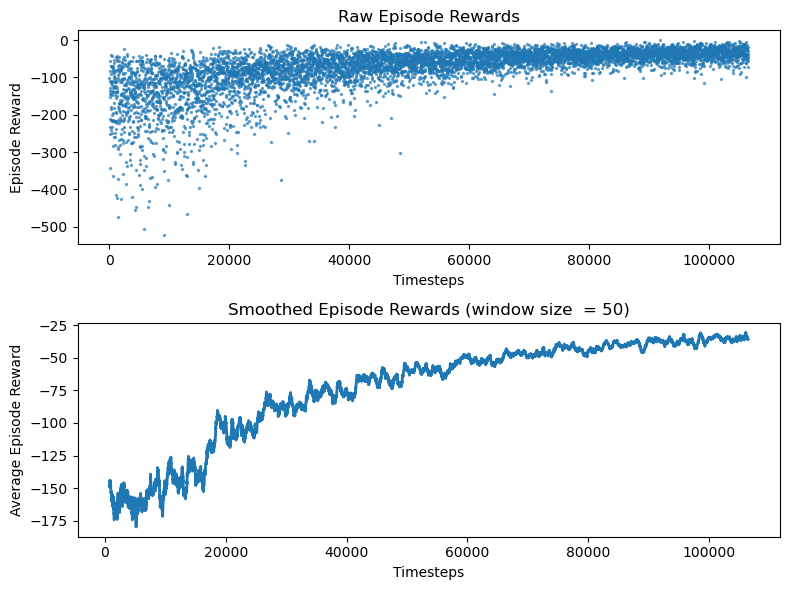

In [ ]:
from stable_baselines3.common.monitor import load_results
from stable_baselines3.common.results_plotter import ts2xy, window_func

df = load_results("results/ppologs/test")
window = 50
df["r_smooth"] = df["r"].rolling(window, min_periods=1).mean()

# convert dataframe (x=timesteps, y=episodic return)
x, y = ts2xy(df, "timesteps")

# plot raw data
plt.figure(figsize=(8, 6))
plt.subplot(2, 1, 1)
plt.scatter(x, y, s=2, alpha=0.6)
plt.xlabel("Timesteps")
plt.ylabel("Episode Reward")
plt.title("Raw Episode Rewards")

# plot smoothed data with custom window
plt.subplot(2, 1, 2)
window = 50
if len(x) >= window:  # Only smooth if we have enough data
    x_smooth, y_smooth = window_func(x, y, 50, np.mean)
    plt.plot(x_smooth, y_smooth, linewidth=2)
    plt.xlabel("Timesteps")
    plt.ylabel("Average Episode Reward")
    plt.title(f"Smoothed Episode Rewards (window size  = {window})")

plt.tight_layout()
plt.show()

## Separate feature extractors

In [7]:
class ActorFeatureExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space: spaces.Box, features_dim: int = 128):
        super().__init__(observation_space, features_dim)
        n_input = observation_space.shape[0]
        self.net = nn.Sequential(
            nn.Linear(n_input, 64),
            nn.ReLU(),
            nn.Linear(64, features_dim),
            nn.ReLU(),
        )

    def forward(self, obs: th.Tensor) -> th.Tensor:
        return self.net(obs)

class CriticFeatureExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space: spaces.Box, features_dim: int = 64):
        super().__init__(observation_space, features_dim)
        n_input = observation_space.shape[0]
        self.net = nn.Sequential(
            nn.Linear(n_input, 128),
            nn.Tanh(),
            nn.Linear(128, features_dim),
            nn.Tanh(),
        )

    def forward(self, obs: th.Tensor) -> th.Tensor:
        return self.net(obs)

class DualExtractorPolicy(ActorCriticPolicy):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def _build_features_extractor(self) -> None:
        """Override to build separate extractors with different architectures."""
        self.features_extractor_pi = ActorFeatureExtractor(self.observation_space)
        self.features_extractor_vf = CriticFeatureExtractor(self.observation_space)


from stable_baselines3.common.envs import DummyVecEnv
import gymnasium as gym

env = DummyVecEnv([lambda: gym.make("CartPole-v1")])

model = PPO(
    DualExtractorPolicy,
    env,
    verbose=1,
)

model.learn(10_000)

ImportError: cannot import name 'DummyVecEnv' from 'stable_baselines3.common.envs' (/home/jeroen/.local/share/miniforge3/envs/traffic/lib/python3.12/site-packages/stable_baselines3/common/envs/__init__.py)